# DGL Example Notebook


## 1. Introduction

This tutorial demonstrates how to build a **graph-based movie recommendation system** using the **Deep Graph Library (DGL)** and a **GraphSAGE encoder**.

Instead of treating ratings as rows in a matrix, we represent the MovieLens dataset as a **heterogeneous bipartite graph**:

- **User nodes**
- **Movie nodes**
- **Edges:** A user *interacted with* (rated) a movie  
- **Node features:** Movie genres + learnable user embeddings

---

### What is Link Prediction?

In graph learning, *link prediction* refers to predicting **missing edges** in a graph.

In our case:

> **Given a user and a movie, should there be an edge between them?**

This directly corresponds to the recommender-system question:

> **Is this movie likely to be relevant or interesting to this user?**

A high predicted score means the model believes a new interaction (a “link”) should exist    i.e., the movie is a good recommendation.

---

### Why Use a Graph Neural Network?

Graph Neural Networks (GNNs) are well-suited because they naturally capture:

- **Neighborhood patterns** (users who watch similar movies)
- **Connectivity structure** (co-watching behavior)
- **Heterogeneous relationships** (user → movie, movie → user)
- **Feature propagation** (movie genres influencing users, and vice versa)

GraphSAGE learns representations by **aggregating information from node neighbors**.  
Thus:

- A movie embedding reflects the genres and the users who watched it  
- A user embedding reflects their movie history and similar users around them  

This context-rich representation improves link prediction quality and enables a more expressive recommender.

---

### What We Will Build

This notebook implements the full end-to-end pipeline:

1. **Load and sample** MovieLens data  
2. **Preprocess** (ID mapping + multi-hot genre features)  
3. **Create chronological train/val/test splits**  
4. **Generate negative samples**  
5. **Construct a DGL heterograph**  
6. **Define a GraphSAGE encoder + MLP link predictor**  
7. **Train the GNN model**  
8. **Evaluate using full-ranking metrics**: Precision@K, Recall@K, NDCG@K  
9. **Generate real recommendations** for any user  

Helper utilities are kept in `dgl_utils.py` to keep the main notebook clean and easy to follow.

We tried to keep this notebook as thin as possible with `dgl_utils.py` doing all the heavy lifting in terms of code. It is well commented and reader friendly should the need arise for the reader to go and explore `dgl_utils.py`.

---


## 2. Setup and Package Imports

We enable autoreload so that any edits to `dgl_utils.py` instantly update inside the notebook.  
Then we import the utilities and core libraries.

In [1]:
%load_ext autoreload
%autoreload 2

In [31]:
import pandas as pd
import numpy as np
import dgl  
import torch

from dgl_utils import (
    load_movielens_data,
    sample_users,
    preprocess_and_save,
    make_splits,
    build_graph,
    build_dataloader,
    evaluate_full_ranking,
    compare_user_preferences,
    recommend_for_user,
    show_recommendations_with_scores
)

import torch.nn as nn
from dgl.nn.pytorch import SAGEConv, HeteroGraphConv
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## 3. Load MovieLens Raw Data




In this step, we load the MovieLens dataset — one of the most widely used benchmark datasets for recommender systems research.

### What is MovieLens?

MovieLens is a long-running project by **GroupLens Research (University of Minnesota)**.  
It contains millions of anonymized user–movie interactions collected from the MovieLens movie recommendation platform.  
The dataset is publicly available, including on Kaggle:

🔗 https://www.kaggle.com/datasets/grouplens/movielens-20m-dataset/

### What Does the Dataset Contain?

For our tutorial, we use two key files:

1. **`rating.csv`**  
   Each row represents a user rating a movie:  
   - `userId` – anonymized user identifier  
   - `movieId` – unique movie identifier  
   - `rating` – rating value (0.5 to 5.0)  
   - `timestamp` – Unix timestamp of interaction  
   
   This is our **interaction signal**, which will form the edges of our graph.

2. **`movie.csv`**  
   Contains movie metadata:  
   - `movieId`  
   - `title`  
   - `genres` (pipe-separated, e.g., *Action|Adventure|Sci-Fi*)  

   These metadata fields form the **node features** for movie nodes.

3. **`genome-tags.csv`**: Master list of tag IDs and descriptions
4. **`genome-scores.csv`**: Movie-tag relevance scores (0.0-1.0)

### What Subset Are We Using?

MovieLens 20M contains:
- **20 million ratings**  
- **27,000 movies**  
- **138,000 users**

**Note**: The data is too large for a deep GNN computation. My local machine would burn and even the zaraton CPU clusters were getting stretched even with a subset of this data. Hence for the purpose of this tutorial we will have to subset the data.
(e.g., 5,000–10,000 users).

The loader function does three things:

1. Reads both CSV files  
2. Ensures the required columns are present  
3. Returns clean DataFrames for preprocessing  

This gives us a reliable starting point for building a GNN-based recommendation system.


In [2]:
ratings_raw, movies_raw = load_movielens_data("data/raw/")

In [3]:
ratings_raw.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [4]:
movies_raw.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
# The respective shapes of the full datasets
print("Shape of Ratings : ", ratings_raw.shape)
print("Shape of Movies : ", movies_raw.shape)

Shape of Ratings :  (20000263, 4)
Shape of Movies :  (27278, 3)


In [6]:
print("No. of unique users : ", ratings_raw['userId'].nunique())
print("No. of unique movies : ", movies_raw['movieId'].nunique())

No. of unique users :  138493
No. of unique movies :  27278


## 4. Sample Subset of Users (Optional for speed)


To keep training lightweight for a tutorial,

we take a random subset of users with at least 20 ratings. I have given you the option to change this to lower or higher (`min_ratings_per_user`) but I found 20 to be reasonable both in terms of getting a decent result and compuation wise. 

This step reduces dataset size but keeps all interactions for sampled users.

Feel free to change `n_users` based on your compute capabilities. 

In [7]:
ratings_sampled, movies_sampled = sample_users(
    ratings_raw,
    movies_raw,
    n_users=10000,              # tuneable (total users - 138493)
    min_ratings_per_user=20,   
    out_dir="data/processed/"
)
ratings_sampled.shape, movies_sampled.shape


Sampled 10000 users, 16404 movies, 1437714 ratings.
Saved to: data/processed/ratings_sampled_raw.csv and data/processed/movies_sampled_raw.csv


((1437714, 4), (16404, 3))

## 5. Preprocess Data

Before building a graph-based recommender, we must **convert the raw MovieLens tables into clean, numerical structures** that a GNN can understand.  
This preprocessing step is crucial — it ensures that user/movie IDs are consistent, features are well-structured, and the dataset is ready for train/val/test splitting.

---

### 1. ID Remapping (userId → user_idx, movieId → movie_idx)

MovieLens uses large, non-contiguous IDs (e.g., `userId = 120934`).  
GNN frameworks like DGL require node IDs to be **dense integers in `[0, N-1]`**.

So we create:

- `user_idx`: maps each unique user to a compact index
- `movie_idx`: maps each unique movie to a compact index

This produces:

| original userId | user_idx |
|-----------------|----------|
| 12              | 0        |
| 998             | 1        |
| 5432            | 2        |

A similar mapping is done for movies.

This step guarantees:
- Graph node indexing is correct  
- Embedding matrices can be created efficiently (e.g., `num_users × embedding_dim`)

---

### 2. Genre Expansion → Multi-Hot Features

MovieLens stores genres as a string like:


Neural networks require **numeric features**, so we convert these into binary indicator columns:

| genre_Action | genre_Adventure | genre_Sci-Fi | ... |
|--------------|-----------------|--------------|-----|
| 1            | 1               | 1            | ... |

This becomes the **feature vector for each movie node** in the GNN.

---

### 3. Attaching Movie Indices

We enrich the movie table with the newly created `movie_idx`.  
We also **drop movies that were never rated** (because they cannot appear in the graph).

---

### 4. Saving Clean, Processed Data

We save three clean files:

- `users.csv` — mapping of userId → user_idx  
- `movies.csv` — movie metadata + genre features + movie_idx  
- `ratings.csv` — interaction table using dense indices

These become the inputs for:
1. Train/val/test splitting  
2. Graph construction  
3. Negative sampling  
4. GNN training  

---

### Why This Matters

A GNN cannot operate on raw CSVs or string IDs.  
Preprocessing ensures:

- **Dense, consistent indexing** for graph nodes  
- **Numerical movie features** for GraphSAGE message passing  
- **Clean filtered tables** that eliminate missing IDs  
- **Reproducibility**—the exact processed files can be reused



In [8]:
preprocess_and_save(ratings_sampled, movies_sampled, out_dir="data/processed/")
print("Preprocessing done.")

Preprocessing done.


In [9]:
movies = pd.read_csv("data/processed/movies.csv")

In [10]:
movies.shape

(16404, 23)

## 6. Train | Val | Test Split

### Temporal Train/Val/Test Split (+ Negative Samples)

To evaluate recommendation quality realistically, we split interactions **per user** in chronological order:

- Early ratings → **Train**
- Middle ratings → **Validation**
- Most recent ratings → **Test**

This simulates predicting what a user will watch **in the future** based on their **past** behavior - the correct setup for real recommender systems.

---

### Why Do We Need Negative Samples?

MovieLens only tells us **positive interactions** (movies a user watched and rated).  
But to train a binary classifier (link predictor), the GNN must also see examples of **non-interactions**, i.e., movies the user *did not* watch.

This is where **negative sampling** comes in:

- For each positive `(user, movie)` pair  
- We randomly sample movies the user never interacted with  
- These become **negative training examples** with label `0`

Example:

| user_idx | movie_idx | label |
|----------|-----------|--------|
| 12       | 50        | 1 (watched) |
| 12       | 300       | 0 (never watched) |

Negative sampling teaches the model the contrast:

> *“These are the kinds of movies a user actually chose vs. the ones they ignored.”*

Without negatives:
- The model cannot learn meaningful preferences  
- Every prediction would look “positive”  

By pairing **positive + negative** examples across train/val/test splits, we prepare the dataset for effective link prediction.


In [11]:
split_dict = make_splits(
    ratings_path="data/processed/ratings.csv",
    out_dir="data/processed/",
    train_ratio=0.7,
    val_ratio=0.1,
    test_ratio=0.2,
    num_neg_per_pos=5.0,
)
split_dict["train_pos"].head()


Data split complete.
Train: 1001999 pos / 5009995 neg
Val:   139612 pos / 698060 neg
Test:  296103 pos / 1480515 neg


,user_idx,movie_idx,rating,timestamp,label
0,0,0,5.0,1997-03-13 17:50:52,1
1,0,16,5.0,1997-03-13 17:50:52,1
2,0,61,5.0,1997-03-13 17:50:52,1
3,0,138,5.0,1997-03-13 17:50:52,1
4,0,629,5.0,1997-03-13 17:50:52,1


## 7. Build DGL Heterograph (Train Graph)

We construct a bipartite graph:

- Nodes: users, movies  
- Edges:
    - `user --rates--> movie`
    - `movie --rev_rates--> user` (reverse edges for GNN message passing)
- Node Features:
    - Movies get multi-hot genre vectors
    - Users get learned embeddings inside the model (no initial features)


In [12]:
g = build_graph(
    ratings_path="data/processed/train_pos.csv",
    movies_path="data/processed/movies.csv",
    out_path="data/graphs/train_graph.bin"
)
g


Graph construction complete (bidirectional).
Users:  10000
Movies: 16404
Edges (rates):      1001999
Edges (rev_rates):  1001999
Saved graph to: data/graphs/train_graph.bin


Graph(num_nodes={'movie': 16404, 'user': 10000},
      num_edges={('movie', 'rev_rates', 'user'): 1001999, ('user', 'rates', 'movie'): 1001999},
      metagraph=[('movie', 'user', 'rev_rates'), ('user', 'movie', 'rates')])

## 8. Define the GNN Model (GraphSAGE Encoder + MLP Predictor)

Our recommender system is powered by a **Graph Neural Network** that learns dense embeddings for users and movies directly from the interaction graph.  
We define three components:

1. **`BipartiteGraphSAGEEncoder`**  
   - Runs **GraphSAGE message passing** on our user–movie heterograph  
   - Learns:
     - User embeddings (trainable vectors)
     - Movie embeddings (from genre features)  
   - Propagates information across edges: `user → movie` and `movie → user`

2. **`MLPLinkPredictor`**  
   - Takes a `(user_emb, movie_emb)` pair  
   - Outputs a probability that this user would interact with this movie  
   - Acts as the final scoring layer of the system

3. **`GNNRecommender`**  
   - Combines encoder + predictor  
   - Handles both training (logits for BCE loss) and evaluation (scores for ranking)

---

### Why place the GNN model inside the notebook?

Although most helper functions live in `dgl_utils.py`, the GNN is the **core learning component** of this tutorial.  
Keeping it inside the notebook:

- Makes the architecture visible and easy to understand  
- Allows readers to modify hidden sizes, layers, or message passing logic  
- Keeps the conceptual flow clear: once the graph is built, we define the model that learns from it  

Hence I decided to take a conscious call and place this rather large piece of code inside the main notebook. It does make the notebook a little less thin but it also makes the reader understand better.


In [13]:

class BipartiteGraphSAGEEncoder(nn.Module):
    """
    Encoder for a user–movie bipartite heterograph with bidirectional edges:

      ('user', 'rates', 'movie')
      ('movie', 'rev_rates', 'user')

    - Users: learnable embeddings
    - Movies: projected from genre features
    - Both node types get updated at each layer.
    """

    def __init__(
        self,
        num_users: int,
        movie_in_dim: int,
        hidden_dim: int = 128,  #tried 64 before, but prefer 128
        out_dim: int = 128,
        num_layers: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.num_users = num_users
        self.movie_in_dim = movie_in_dim
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        self.num_layers = num_layers
        self.dropout = dropout

        # --- User embedding table (no initial features) ---
        self.user_embedding = nn.Embedding(num_users, hidden_dim)

        # --- Project movie genre features into the same space as users ---
        self.movie_input_proj = nn.Linear(movie_in_dim, hidden_dim)

        # --- GraphSAGE layers over both edge types ---
        self.convs = nn.ModuleList()
        self.bns_user = nn.ModuleList()
        self.bns_movie = nn.ModuleList()

        in_dim = hidden_dim
        for layer in range(num_layers):
            out_dim_layer = hidden_dim if layer < num_layers - 1 else out_dim

            conv = HeteroGraphConv(
                {
                    "rates": SAGEConv(
                        in_feats=in_dim,
                        out_feats=out_dim_layer,
                        aggregator_type="mean",
                    ),
                    "rev_rates": SAGEConv(
                        in_feats=in_dim,
                        out_feats=out_dim_layer,
                        aggregator_type="mean",
                    ),
                },
                aggregate="sum",
            )
            self.convs.append(conv)

            # Separate BN for user and movie
            self.bns_user.append(nn.BatchNorm1d(out_dim_layer))
            self.bns_movie.append(nn.BatchNorm1d(out_dim_layer))

            in_dim = out_dim_layer

        self.activation = nn.LeakyReLU(0.1)
        self.dropout_layer = nn.Dropout(dropout)

        # Final projection for users if needed
        if hidden_dim != out_dim:
            self.user_out_proj = nn.Linear(hidden_dim, out_dim)
        else:
            self.user_out_proj = nn.Identity()

    def forward(self, g: dgl.DGLHeteroGraph):
        """
        Returns:
          user_emb [num_users, out_dim]
          movie_emb [num_movies, out_dim]
        """
        device = next(self.parameters()).device
        g = g.to(device)

        # Initial node features
        h_user = self.user_embedding.weight           # [num_users, hidden_dim]
        movie_genre = g.nodes["movie"].data["genre"].to(device)
        h_movie = self.movie_input_proj(movie_genre)  # [num_movies, hidden_dim]

        for layer, (conv, bn_u, bn_m) in enumerate(
            zip(self.convs, self.bns_user, self.bns_movie)
        ):
            h_dict = {
                "user": h_user,
                "movie": h_movie,
            }

            # HeteroGraphConv updates both user and movie
            h_new = conv(g, h_dict)  # dict with 'user' and 'movie'

            h_user_new = bn_u(h_new["user"])
            h_movie_new = bn_m(h_new["movie"])

            h_user_new = self.activation(h_user_new)
            h_movie_new = self.activation(h_movie_new)

            h_user_new = self.dropout_layer(h_user_new)
            h_movie_new = self.dropout_layer(h_movie_new)

            # Residual connections where dims match
            if h_user_new.shape == h_user.shape:
                h_user = h_user + h_user_new
            else:
                h_user = h_user_new

            if h_movie_new.shape == h_movie.shape:
                h_movie = h_movie + h_movie_new
            else:
                h_movie = h_movie_new

        # Final projection for users to out_dim
        h_user_out = self.user_out_proj(h_user)

        return h_user_out, h_movie


class MLPLinkPredictor(nn.Module):
    """
    Link prediction head operating on concatenated user & movie embeddings.

    Given:
      - user_emb[u]  [B, d]
      - movie_emb[m] [B, d]

    We build [u || m] and push through an MLP to get a logit.
    """

    def __init__(
        self,
        emb_dim: int,
        hidden_dim: int = 128,
        dropout: float = 0.3,
    ):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(2 * emb_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, user_emb, movie_emb, user_idx, movie_idx):
        """
        Parameters
        ----------
        user_emb : [num_users, d]
        movie_emb: [num_movies, d]
        user_idx : [B] long
        movie_idx: [B] long

        Returns
        -------
        logits : [B] (before sigmoid)
        """
        u = user_emb[user_idx]   # [B, d]
        m = movie_emb[movie_idx] # [B, d]

        x = torch.cat([u, m], dim=-1)  # [B, 2d]
        logits = self.mlp(x).squeeze(-1)  # [B]

        return logits


class GNNRecommender(nn.Module):
    """
    Full model: GraphSAGE encoder + link prediction head.

    Usage pattern in training:
        user_emb, movie_emb = model.encode(g)
        logits = model.predict(user_emb, movie_emb, user_idx, movie_idx)
        loss = BCEWithLogitsLoss(logits, labels)
    """

    def __init__(
        self,
        num_users: int,
        movie_feat_dim: int,
        encoder_hidden_dim: int = 128, # was 64
        encoder_out_dim: int = 128,    # was 64
        encoder_layers: int = 2,
        encoder_dropout: float = 0.2,
        lp_hidden_dim: int = 256,     # was 128
        lp_dropout: float = 0.3,
    ):
        super().__init__()

        self.encoder = BipartiteGraphSAGEEncoder(
            num_users=num_users,
            movie_in_dim=movie_feat_dim,
            hidden_dim=encoder_hidden_dim,
            out_dim=encoder_out_dim,
            num_layers=encoder_layers,
            dropout=encoder_dropout,
        )

        self.link_predictor = MLPLinkPredictor(
            emb_dim=encoder_out_dim,
            hidden_dim=lp_hidden_dim,
            dropout=lp_dropout,
        )

    def encode(self, g: dgl.DGLHeteroGraph):
        """
        Returns:
          user_emb [num_users, d]
          movie_emb [num_movies, d]
        """
        return self.encoder(g)

    def predict_scores(self, g, user_idx, movie_idx):
        """
        Convenience wrapper:
        Returns sigmoid probabilities in [0,1].
        """
        user_emb, movie_emb = self.encode(g)
        logits = self.link_predictor(user_emb, movie_emb, user_idx, movie_idx)
        probs = torch.sigmoid(logits)
        return probs

    def forward(self, g, user_idx, movie_idx):
        """
        Forward used during training:
        Returns logits (before sigmoid), suitable for BCEWithLogitsLoss.
        """
        user_emb, movie_emb = self.encode(g)
        logits = self.link_predictor(user_emb, movie_emb, user_idx, movie_idx)
        return logits


## 9. Train the Model

We train using:

- BCEWithLogitsLoss
- Negative sampling from train_neg.csv
- GraphSAGE encoder + MLP link predictor

Training stays small for the tutorial.

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GNNRecommender(
    num_users=g.num_nodes("user"),
    movie_feat_dim=g.nodes["movie"].data["genre"].shape[1],
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

train_loader, total_samples = build_dataloader(
    "data/processed/train_pos.csv",
    "data/processed/train_neg.csv",
    batch_size=2048,
    shuffle=True
)

print(f"Training samples: {total_samples}")

Training samples: 6011994


## 10. Training Loop

A simple loop for demonstration.

Feel free to change the `epochs` as required.

In [15]:

epochs = 20 # user can change this freely

epoch_losses = []   # store losses for plotting

for ep in range(1, epochs+1):
    model.train()
    epoch_loss = 0

    for user_idx, movie_idx, labels in train_loader:
        user_idx = user_idx.to(device)
        movie_idx = movie_idx.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(g, user_idx, movie_idx)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(labels)

    epoch_loss /= total_samples
    epoch_losses.append(epoch_loss)

    print(f"Epoch {ep}/{epochs} — Loss = {epoch_loss:.4f}")



Epoch 1/20 — Loss = 0.1793
Epoch 2/20 — Loss = 0.1504
Epoch 3/20 — Loss = 0.1439
Epoch 4/20 — Loss = 0.1390
Epoch 5/20 — Loss = 0.1351
Epoch 6/20 — Loss = 0.1323
Epoch 7/20 — Loss = 0.1297
Epoch 8/20 — Loss = 0.1279
Epoch 9/20 — Loss = 0.1263
Epoch 10/20 — Loss = 0.1247
Epoch 11/20 — Loss = 0.1232
Epoch 12/20 — Loss = 0.1221
Epoch 13/20 — Loss = 0.1210
Epoch 14/20 — Loss = 0.1200
Epoch 15/20 — Loss = 0.1191
Epoch 16/20 — Loss = 0.1182
Epoch 17/20 — Loss = 0.1175
Epoch 18/20 — Loss = 0.1167
Epoch 19/20 — Loss = 0.1160
Epoch 20/20 — Loss = 0.1154


### 10.1 Training Loss Curve

The plot below shows how the model’s loss decreases over training epochs.
Because the notebook stores all epoch losses in a Python list, the chart
updates automatically if you change the number of training epochs above.

You can experiment with:
- Increasing epochs
- Changing batch size
- Switching optimizer or learning rate

The curve helps us visualize convergence and diagnose underfitting or overfitting.

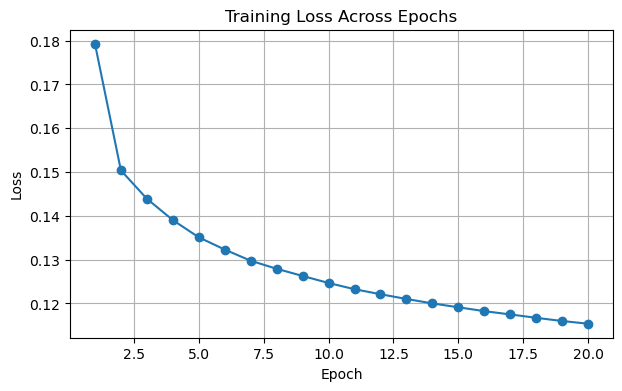

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), epoch_losses, marker='o')
plt.title("Training Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## 11. Full-Ranking Evaluation

Once the model is trained, we evaluate it in the **most realistic recommendation setting**:  
for each user, we ask the model to **rank every movie in the catalog** and measure how well the top-K results match the movies the user actually interacted with in the validation set.

This is called **full-ranking evaluation**, and it is significantly more challenging than simple accuracy on sampled pairs.

### What happens during evaluation?

For each user in the validation set:

1. **Score all movies**  
   - The model computes a relevance score for *every* movie (thousands of predictions per user).  
   - This simulates a real recommender system where we must choose the best items from a large pool.

2. **Sort movies by predicted score**  
   - Higher score ⇒ more likely the user would interact with it.  
   - We then take the **top-K recommendations**.

3. **Compare with the user’s true positives**  
   Using the validation set (which contains “held-out” historical interactions), we compute:

   - **Precision@K**  
     - Of the top-K recommendations, how many were actually relevant?  
     - Measures *quality* of the top recommendations.

   - **Recall@K**  
     - Of all relevant movies for this user, how many did we successfully recommend?  
     - Measures *coverage* of relevant items.

   - **NDCG@K (Normalized Discounted Cumulative Gain)**  
     - Gives more weight to relevant items ranked **higher**.  
     - Captures the *ranking quality* of the entire top-K list.

### Why this evaluation matters

This setup mirrors a real production recommender system:

- The model must distinguish good recommendations from thousands of possible movies.
- Metrics reflect the *actual user experience*:  
  “Did the top-10 suggestions include movies the user might really watch?”

Unlike sampled or pairwise metrics, **full-ranking evaluation** gives a holistic, system-level view of recommendation quality and is the standard for modern recommender research.


In [17]:
metrics = evaluate_full_ranking(
    model=model,
    g=g,
    pos_path="data/processed/val_pos.csv",
    k=10,
    device=device
)

metrics


Evaluating 10000 users with full ranking...


100%|██████████| 10000/10000 [02:38<00:00, 62.98it/s]


{'precision@k': 0.02245,
 'recall@k': 0.0377051729696023,
 'ndcg@k': 0.027997733354749425,
 'num_users': 10000}

## 12. Demonstration: Top-10 Personalized Recommendations (with Model Confidence Scores)

The table below shows a qualitative demonstration of our GNN recommender
system. For a selected user, we:

1. Compute the user's embedding from the trained GNN.
2. Score *every* movie in the catalog using the learned link-prediction head.
3. Rank the movies by predicted score.
4. Show the Top-10 recommendations along with their confidence values.

The `score` column reflects the model's belief (after applying a sigmoid)
that the user would interact with or like the movie.  
Higher scores indicate stronger recommendations.

This section demonstrates how the system behaves end-to-end for a real user.


In [18]:
user = 13  # or any user from your sample
movies = pd.read_csv("data/processed/movies.csv")
show_recommendations_with_scores(
    user_id=user, model=model, g=g, movies_df=movies, k=10, device=device
)

,rank,title,genres,score
0,1,Ace Ventura: Pet Detective (1994),Comedy,0.9988
1,2,Natural Born Killers (1994),Action|Crime|Thriller,0.9988
2,3,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.9988
3,4,Interview with the Vampire: The Vampire Chroni...,Drama|Horror,0.9986
4,5,Batman Forever (1995),Action|Adventure|Comedy|Crime,0.9983
5,6,Batman (1989),Action|Crime|Thriller,0.9982
6,7,Apollo 13 (1995),Adventure|Drama|IMAX,0.9980
7,8,Dances with Wolves (1990),Adventure|Drama|Western,0.9978
8,9,Dumb & Dumber (Dumb and Dumber) (1994),Adventure|Comedy,0.9977
9,10,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,0.9974


## 13. Bonus: Adding Semantic Tag Nodes (MovieLens Genome Tags)

### Why extend the graph?

So far, our recommender system uses a **bipartite graph**:

- **User nodes**
- **Movie nodes**
- **Edges:** user → movie (“rates”)

This models who rated what, but ignores *why* they liked the movie.  
MovieLens provides a powerful extra resource: **Genome Tags**.

Genome tags are human-curated descriptors such as:

- “emotional”
- “dark humor”
- “time travel”
- “strong female lead”

Each tag comes with a **relevance score** (0.0 → 1.0) indicating how strongly it applies to a movie.

### What we add: a *heterogeneous graph*

A **heterogeneous graph (heterograph)** is a graph with:

- **Multiple node types**  
- **Multiple relation/edge types**

In our case:

#### Node types
- `user`
- `movie`
- `tag`  *(new)*

#### Edge types
- `user --rates--> movie`
- `movie --rev_rates--> user`
- `movie --has_tag--> tag`  *(new)*
- `tag --tag_of--> movie`  *(new)*


This transforms our recommender into a **knowledge-aware system**.  
Information now flows through semantic paths such as:


### What we actually build

We load the MovieLens genome tag files:

- `genome-tags.csv`: master list of tagId → tag text  
- `genome-scores.csv`: movieId, tagId, relevance score  

We then:

1. Keep only strong associations (relevance ≥ 0.8).  
2. Map movieId → movie_idx and tagId → tag_idx.  
3. Add edges:
   - `movie → tag`
   - `tag → movie`


In [19]:
from dgl_utils import load_genome_tags, build_movie_tag_edges, build_hetero_graph

# Load genome metadata
tags_df, scores_df = load_genome_tags("data/raw/")


In [20]:
tags_df.head()

,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s


In [21]:
scores_df.head()

,movieId,tagId,relevance
0,1,1,0.02500
1,1,2,0.02500
2,1,3,0.05775
3,1,4,0.09675
4,1,5,0.14675


In [22]:
# The respective shapes of the  datasets
print("Shape of Tags : ", tags_df.shape)
print("Shape of Scores : ", scores_df.shape)

Shape of Tags :  (1128, 2)
Shape of Scores :  (11709768, 3)


In [23]:
movies_df = pd.read_csv("data/processed/movies.csv")

movie_tag_edges, tagId_to_idx = build_movie_tag_edges(
    movies_df,
    genome_scores_path="data/raw/genome_scores.csv",
    relevance_threshold=0.8
)

movie_tag_edges.head()

Movie–Tag Edge Summary:
  Movies with tags: 10058 out of 16404
  Num tag types: 1104
  Num edges: 102151


,movie_idx,tag_idx
28,0,28
62,0,61
63,0,62
185,0,178
192,0,185


## 13.1 Constructing the Full Heterogeneous Graph

We now merge:
- **User → Movie** edges (training interactions)  
- **Movie → Tag** edges (semantic relationships)  

The resulting graph supports *three node types*:
- `user`
- `movie`
- `tag`

and *four edge types*:
- `user --rates--> movie`  
- `movie --rev_rates--> user`  
- `movie --has_tag--> tag`  
- `tag --tag_of--> movie`  

This is a true **heterogeneous knowledge graph**.

In [24]:
from dgl_utils import build_hetero_graph

train_pos = pd.read_csv("data/processed/train_pos.csv")

g_hetero = build_hetero_graph(
    train_pos=train_pos,
    movies_df=movies_df,
    movie_tag_edges=movie_tag_edges
)

g_hetero


Heterogeneous Graph Summary:
Graph(num_nodes={'movie': 16404, 'tag': 1104, 'user': 10000},
      num_edges={('movie', 'has_tag', 'tag'): 102151, ('movie', 'rev_rates', 'user'): 1001999, ('tag', 'tag_of', 'movie'): 102151, ('user', 'rates', 'movie'): 1001999},
      metagraph=[('movie', 'tag', 'has_tag'), ('movie', 'user', 'rev_rates'), ('tag', 'movie', 'tag_of'), ('user', 'movie', 'rates')])


Graph(num_nodes={'movie': 16404, 'tag': 1104, 'user': 10000},
      num_edges={('movie', 'has_tag', 'tag'): 102151, ('movie', 'rev_rates', 'user'): 1001999, ('tag', 'tag_of', 'movie'): 102151, ('user', 'rates', 'movie'): 1001999},
      metagraph=[('movie', 'tag', 'has_tag'), ('movie', 'user', 'rev_rates'), ('tag', 'movie', 'tag_of'), ('user', 'movie', 'rates')])

## 13.2 Training a GNN on the Heterogeneous Graph

Our previous bipartite GraphSAGE encoder handled only:
- user nodes  
- movie nodes  

Now we have a third node type:
- tag nodes  

This requires updating the encoder architecture to:

### 1. Learn embeddings for `tag` nodes
Tags have no features, so they start with **learned embedding vectors** just like users.

### 2. Add GraphSAGE relations for movie↔tag edges
Semantic information now flows between movies and tags during neighborhood aggregation.

### 3. Include all four relations in message passing:

- `rates`  
- `rev_rates`  
- `has_tag`  
- `tag_of`  

Each relation requires a corresponding SAGEConv operation inside the heterograph layer.

The final effect is a GNN that jointly learns:

- What users like  
- What movies represent  
- What semantic concepts link movies together 

In [25]:
# Upgraded GraphSAGE Encoder (Supports Tag Nodes)

class HeteroGraphSAGEEncoder(nn.Module):
    """
    Encoder for a 3-type heterograph:
      user, movie, tag
    with 4 edge types:
      user --rates--> movie
      movie --rev_rates--> user
      movie --has_tag--> tag
      tag   --tag_of--> movie
    """
    def __init__(self, num_users, num_movies, num_tags, movie_feat_dim,
                 hidden_dim=128, out_dim=128, num_layers=2, dropout=0.2):
        super().__init__()

        # Embeddings for user and tag nodes
        self.user_embedding = nn.Embedding(num_users, hidden_dim)
        self.tag_embedding = nn.Embedding(num_tags, hidden_dim)

        # Project movie feature vectors
        self.movie_proj = nn.Linear(movie_feat_dim, hidden_dim)

        # Create hetero GraphSAGE layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroGraphConv(
                {
                    "rates":    SAGEConv(hidden_dim, hidden_dim, "mean"),
                    "rev_rates": SAGEConv(hidden_dim, hidden_dim, "mean"),
                    "has_tag":  SAGEConv(hidden_dim, hidden_dim, "mean"),
                    "tag_of":   SAGEConv(hidden_dim, hidden_dim, "mean"),
                },
                aggregate="sum",
            )
            self.layers.append(conv)

        self.dropout = nn.Dropout(dropout)
        self.act = nn.LeakyReLU(0.1)

    def forward(self, g):
        h = {
            "user": self.user_embedding.weight,
            "movie": self.movie_proj(g.nodes["movie"].data["genre"]),
            "tag": self.tag_embedding.weight,
        }

        for conv in self.layers:
            h_new = conv(g, h)
            h = {ntype: self.act(self.dropout(h_new[ntype])) for ntype in h_new}

        return h["user"], h["movie"]



In [26]:
# New recommender class that supports the hetero use case
class GNNRecommender_Hetero(nn.Module):
    """
    Recommender for heterogeneous GNN:
      HeteroGraphSAGEEncoder + MLP link predictor.
    """
    def __init__(
        self,
        num_users: int,
        num_movies: int,
        num_tags: int,
        movie_feat_dim: int,
        encoder_hidden_dim: int = 128,
        encoder_out_dim: int = 128,
        encoder_layers: int = 2,
        encoder_dropout: float = 0.2,
        lp_hidden_dim: int = 256,
        lp_dropout: float = 0.3,
    ):
        super().__init__()

        self.encoder = HeteroGraphSAGEEncoder(
            num_users=num_users,
            num_movies=num_movies,
            num_tags=num_tags,
            movie_feat_dim=movie_feat_dim,
            hidden_dim=encoder_hidden_dim,
            out_dim=encoder_out_dim,
            num_layers=encoder_layers,
            dropout=encoder_dropout,
        )

        # Same MLP predictor as before — reuse your existing class
        self.link_predictor = MLPLinkPredictor(
            emb_dim=encoder_out_dim,
            hidden_dim=lp_hidden_dim,
            dropout=lp_dropout,
        )

    def encode(self, g):
        return self.encoder(g)

    def predict_scores(self, g, user_idx, movie_idx):
        user_emb, movie_emb = self.encode(g)
        logits = self.link_predictor(user_emb, movie_emb, user_idx, movie_idx)
        probs = torch.sigmoid(logits)
        return probs

    def forward(self, g, user_idx, movie_idx):
        user_emb, movie_emb = self.encode(g)
        logits = self.link_predictor(user_emb, movie_emb, user_idx, movie_idx)
        return logits


## 13.3 Integrating the Encoder Into the Recommender

Once we switch the encoder to the heterograph version, the training loop, loss function,  
negative sampling, and evaluation procedure remain exactly the same.

The only difference is:

- The graph now has more structure  
- The encoder uses more information  
- Movie embeddings are enriched with tag semantics  

This typically yields better downstream metrics:
- Recall@K  
- Precision@K  
- NDCG@K  



In [27]:
model = GNNRecommender_Hetero(
    num_users=g_hetero.num_nodes("user"),
    num_movies=g_hetero.num_nodes("movie"),
    num_tags=g_hetero.num_nodes("tag"),
    movie_feat_dim=g_hetero.nodes["movie"].data["genre"].shape[1],
).to(device)

## 13.4 Training the new model

In [28]:
train_loader, total_samples = build_dataloader(
    "data/processed/train_pos.csv",
    "data/processed/train_neg.csv",
    batch_size=2048,
    shuffle=True
)


In [29]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

epochs = 20  # you can increase if compute allows
epoch_losses = []

for ep in range(1, epochs+1):
    model.train()
    total_loss = 0

    for user_idx, movie_idx, labels in train_loader:
        user_idx = user_idx.to(device)
        movie_idx = movie_idx.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Training step on heterograph
        logits = model(g_hetero, user_idx, movie_idx)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)

    avg_loss = total_loss / total_samples
    epoch_losses.append(avg_loss)

    print(f"Epoch {ep}/{epochs} — Loss = {avg_loss:.4f}")


Epoch 1/20 — Loss = 0.1835
Epoch 2/20 — Loss = 0.1568
Epoch 3/20 — Loss = 0.1510
Epoch 4/20 — Loss = 0.1475
Epoch 5/20 — Loss = 0.1444
Epoch 6/20 — Loss = 0.1415
Epoch 7/20 — Loss = 0.1396
Epoch 8/20 — Loss = 0.1380
Epoch 9/20 — Loss = 0.1366
Epoch 10/20 — Loss = 0.1355
Epoch 11/20 — Loss = 0.1345
Epoch 12/20 — Loss = 0.1336
Epoch 13/20 — Loss = 0.1329
Epoch 14/20 — Loss = 0.1323
Epoch 15/20 — Loss = 0.1317
Epoch 16/20 — Loss = 0.1311
Epoch 17/20 — Loss = 0.1306
Epoch 18/20 — Loss = 0.1302
Epoch 19/20 — Loss = 0.1297
Epoch 20/20 — Loss = 0.1292


### 13.5 Evaluation of the Knowledge-Aware GNN

Evaluation proceeds identically using **full ranking**:

For each user:
1. Score every movie  
2. Sort by predicted relevance  
3. Compute:  
   - Precision@10  
   - Recall@10  
   - NDCG@10  

In [30]:
metrics = evaluate_full_ranking(
    model=model,
    g=g_hetero,
    pos_path="data/processed/val_pos.csv",
    k=10,
    device=device
)

metrics

Evaluating 10000 users with full ranking...


100%|██████████| 10000/10000 [03:34<00:00, 46.56it/s]


{'precision@k': 0.023710000000000002,
 'recall@k': 0.04155457967130444,
 'ndcg@k': 0.030635055607094414,
 'num_users': 10000}